In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR = "/content/drive/MyDrive/nlp_project"
SAVE_DIR = os.path.join(BASE_DIR, "saved_model")
DATA_PATH = "/content/train.csv"

os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive


In [2]:
!pip install -U transformers datasets evaluate scikit-learn textattack matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 29.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 67.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 96.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 445.7/445.7 kB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [8]:
from datasets import load_dataset

dataset = load_dataset("glue", "sst2")

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})


In [9]:
sample = dataset["train"][0]

print("Sentence:", sample["sentence"])
print("Label:", sample["label"])

Sentence: hide new secretions from the parental units 
Label: 0


In [10]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_function(examples):
    return tokenizer(
        examples["sentence"],
        padding="max_length",
        truncation=True
    )

tokenized_datasets = dataset.map(tokenize_function, batched=True)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

In [11]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [12]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir=SAVE_DIR,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"]
)

In [13]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Step,Training Loss
500,0.349200
1000,0.268500
1500,0.235000
2000,0.218700
2500,0.207900
3000,0.200400
3500,0.198700
4000,0.185300
4500,0.146900
5000,0.131300


TrainOutput(global_step=8420, training_loss=0.1767222261768622, metrics={'train_runtime': 6761.6574, 'train_samples_per_second': 19.921, 'train_steps_per_second': 1.245, 'total_flos': 1.7843093664165888e+16, 'train_loss': 0.1767222261768622, 'epoch': 2.0})

In [14]:
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

('/content/drive/MyDrive/nlp_project/saved_model/tokenizer_config.json',
 '/content/drive/MyDrive/nlp_project/saved_model/special_tokens_map.json',
 '/content/drive/MyDrive/nlp_project/saved_model/vocab.txt',
 '/content/drive/MyDrive/nlp_project/saved_model/added_tokens.json',
 '/content/drive/MyDrive/nlp_project/saved_model/tokenizer.json')

In [15]:
print(os.listdir(SAVE_DIR))

['runs', 'checkpoint-500', 'checkpoint-1000', 'checkpoint-1500', 'checkpoint-2000', 'checkpoint-2500', 'checkpoint-3000', 'checkpoint-3500', 'checkpoint-4000', 'checkpoint-4500', 'checkpoint-5000', 'checkpoint-5500', 'checkpoint-6000', 'checkpoint-6500', 'checkpoint-7000', 'checkpoint-7500', 'checkpoint-8000', 'checkpoint-8420', 'config.json', 'model.safetensors', 'training_args.bin', 'tokenizer_config.json', 'special_tokens_map.json', 'vocab.txt', 'tokenizer.json']


In [16]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR)
tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)

In [17]:
from textattack.models.wrappers import HuggingFaceModelWrapper
from textattack.attack_recipes import TextFoolerJin2019

model_wrapper = HuggingFaceModelWrapper(model, tokenizer)
attack = TextFoolerJin2019.build(model_wrapper)

textattack: Updating TextAttack package dependencies.
textattack: Downloading NLTK required packages.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package omw to /root/nltk_data...
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Unzipping taggers/universal_tagset.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape s

In [22]:
!pip install -U nltk textattack

import nltk
nltk.download('all')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.8 MB/s eta 0:00:00
  Attempting uninstall: nltk
    Found existing installation: nltk 3.9.1
    Uninstalling nltk-3.9.1:
      Successfully uninstalled nltk-3.9.1


[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root

True

In [30]:
from textattack.attack_results import SuccessfulAttackResult

In [31]:
results = []

for i in range(3):

    sample = dataset["validation"][i]

    text = sample["sentence"]
    label = sample["label"]

    try:

        result = attack.attack(text, label)

        results.append({
            "original": text,
            "label": int(label),
            "adversarial": result.perturbed_text(),
            "success": isinstance(result, SuccessfulAttackResult)
        })

        print(f"Done {i+1}/3")

    except Exception as e:

        print("Error:", e)\


Done 1/3
Done 2/3
Done 3/3


In [32]:
import pandas as pd

df = pd.DataFrame(results)

df

,original,label,adversarial,success
0,it 's a charming and often affecting journey .,1,it 's a leggy and often afflicted journey .,True
1,unflinchingly bleak and desperate,0,unflinchingly eerie and desperate,True
2,allows us to hope that nolan is poised to emba...,1,allows us to hope that nolan is prepped to emb...,True


In [33]:
success_rate = sum(r["success"] for r in results) / len(results)
print(success_rate)

1.0


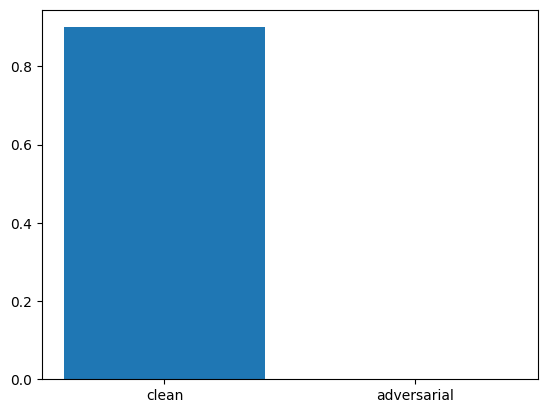

In [34]:
import matplotlib.pyplot as plt

clean_acc = 0.90
adv_acc = 1 - success_rate

plt.bar(["clean", "adversarial"], [clean_acc, adv_acc])
plt.show()

In [35]:
import json

with open("attack_results.json", "w") as f:
    json.dump(results, f, indent=2)

In [36]:
df.to_csv(
    "/content/drive/MyDrive/nlp_project/adversarial_results.csv",
    index=False
)